**Data Acquisition, Preprocessing, and EDA**

--- Loading Data ---
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
t

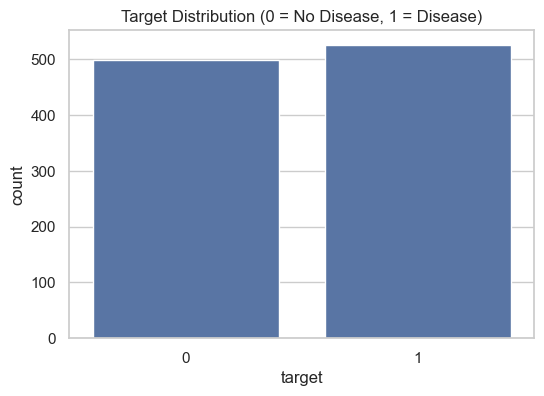

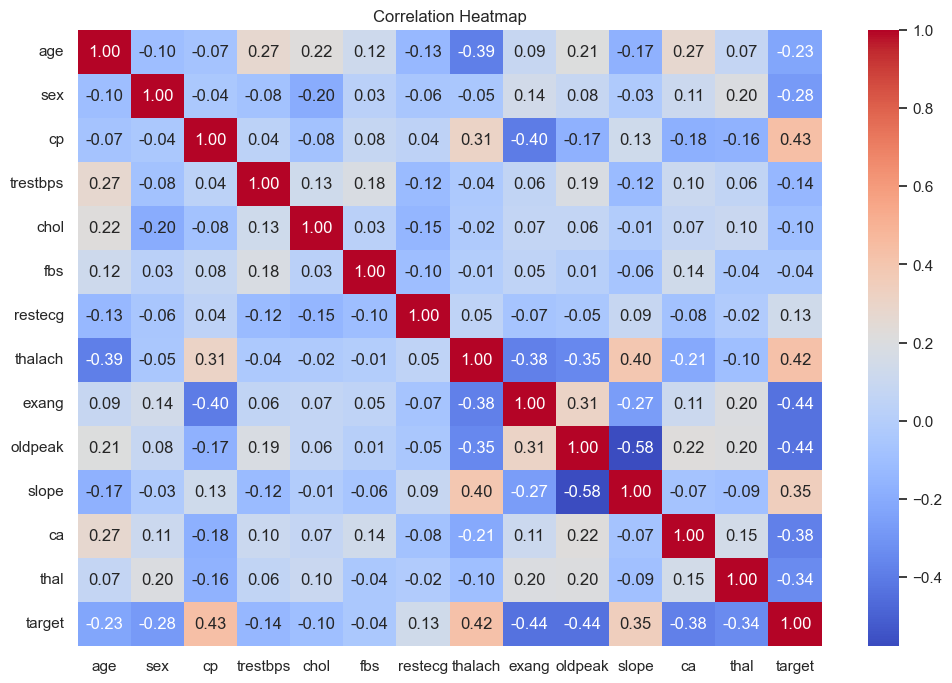

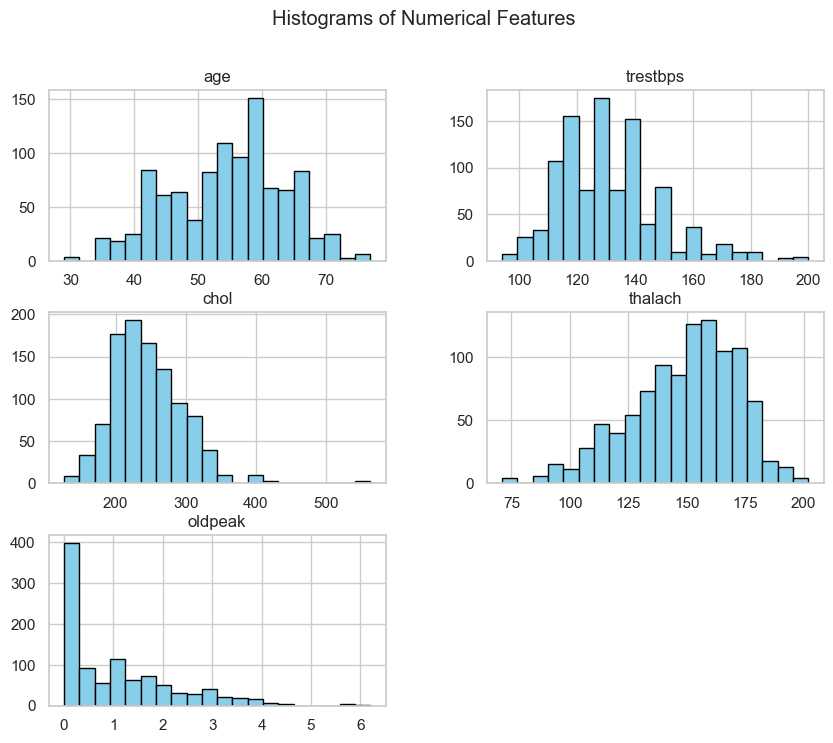

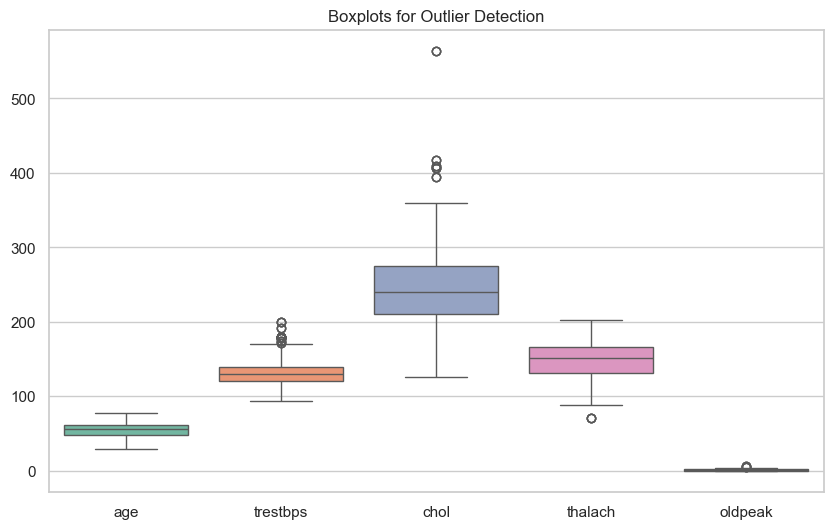

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# 1. Data Acquisition
print("--- Loading Data ---")
df = pd.read_csv('data/heart.csv')

# Basic info
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# 2. Exploratory Data Analysis (EDA)
print("\n--- Exploratory Data Analysis ---")

# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Target Distribution (0 = No Disease, 1 = Disease)')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Distributions of numerical features
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df[numerical_features].hist(bins=20, figsize=(10, 8), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Features')
plt.show()

# Outliers detection (Boxplots)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numerical_features], palette='Set2')
plt.title('Boxplots for Outlier Detection')
plt.show()


--- Data Preprocessing ---
Data shape after dropping duplicates: (302, 14)

--- Model 1: Random Forest Classifier ---
Best Params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
Accuracy:  0.7705
Precision: 0.7714
Recall:    0.8182
F1-Score:  0.7941
ROC-AUC:   0.8539


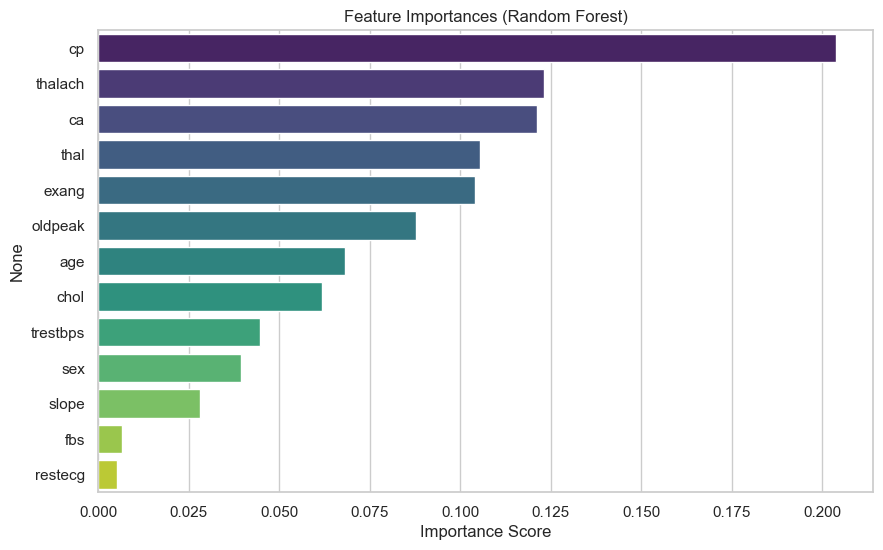


--- Model 2: Support Vector Machine (SVM) ---
Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy:  0.8197
Precision: 0.8056
Recall:    0.8788
F1-Score:  0.8406
ROC-AUC:   0.8712


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC # Support Vector Machine
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("\n--- Data Preprocessing ---")
# Drop duplicates to prevent data leakage
df_cleaned = df.drop_duplicates()
print(f"Data shape after dropping duplicates: {df_cleaned.shape}")

# Separate Features (X) and Target (y)
X = df_cleaned.drop('target', axis=1)
y = df_cleaned['target']

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
# Note: Categorical features are already label-encoded in this dataset.

# Feature scaling (Standardization)
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- Model 1: Random Forest Classifier ---")
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

# Random Forest Predictions
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print("Best Params:", rf_grid.best_params_)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")

# Feature Importance Plot
feature_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))

# Updated line here:
sns.barplot(x=feature_importances.values, y=feature_importances.index, hue=feature_importances.index, palette='viridis', legend=False)

plt.title('Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.show()

print("\n--- Model 2: Support Vector Machine (SVM) ---")
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm = SVC(probability=True, random_state=42)
svm_grid = GridSearchCV(svm, svm_params, cv=5, scoring='accuracy')
svm_grid.fit(X_train, y_train)
best_svm = svm_grid.best_estimator_

# SVM Predictions
y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]

print("Best Params:", svm_grid.best_params_)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_svm):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_svm):.4f}")

**NEW PATIENT DATA**

          DIAGNOSTIC PREDICTION REPORT
Diagnosis      : HIGH RISK OF HEART DISEASE DETECTED
Recommendation : Please consult a cardiologist immediately.
--------------------------------------------------
Probability of Heart Disease    : 79.71%
Probability of No Heart Disease : 20.29%


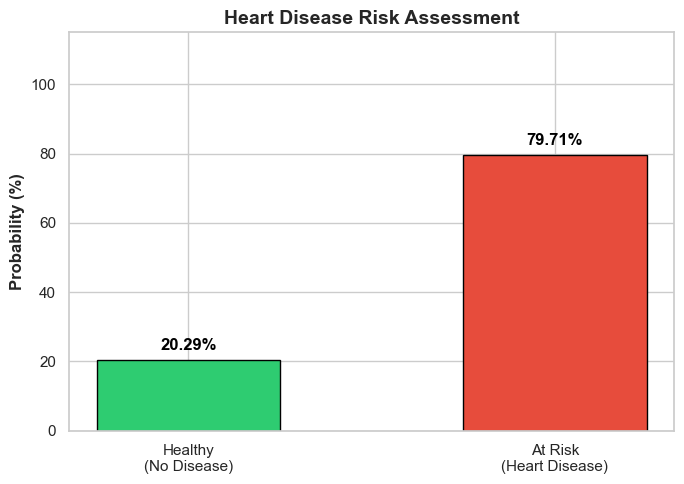

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 1: INPUT NEW PATIENT DATA
# ==========================================
# Example patient data: age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal
patient_data = [[55, 1, 2, 140, 250, 0, 1, 150, 0, 1.5, 1, 0, 2]]

# Feature names exactly as they appear in the original dataset
feature_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

# Convert to Pandas DataFrame
patient_df = pd.DataFrame(patient_data, columns=feature_names)

# Scale the numerical features using the ALREADY TRAINED 'scaler'
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
patient_df[numerical_features] = scaler.transform(patient_df[numerical_features])

# ==========================================
# STEP 2: PREDICTION AND PROBABILITY
# ==========================================
# Predict using the ALREADY TRAINED 'best_svm' model
predicted_class = best_svm.predict(patient_df)[0]
probabilities = best_svm.predict_proba(patient_df)[0]

prob_no_disease = probabilities[0] * 100
prob_disease = probabilities[1] * 100

# ==========================================
# STEP 3: PROFESSIONAL DIAGNOSTIC REPORT
# ==========================================
print("=" * 50)
print("          DIAGNOSTIC PREDICTION REPORT")
print("=" * 50)

if predicted_class == 1:
    print("Diagnosis      : HIGH RISK OF HEART DISEASE DETECTED")
    print("Recommendation : Please consult a cardiologist immediately.")
else:
    print("Diagnosis      : LOW RISK OF HEART DISEASE")
    print("Recommendation : The patient is likely healthy.")

print("-" * 50)
print(f"Probability of Heart Disease    : {prob_disease:.2f}%")
print(f"Probability of No Heart Disease : {prob_no_disease:.2f}%")
print("=" * 50)

# ==========================================
# STEP 4: VISUALIZE RISK ASSESSMENT
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

categories = ['Healthy\n(No Disease)', 'At Risk\n(Heart Disease)']
probs = [prob_no_disease, prob_disease]
colors = ['#2ecc71', '#e74c3c']  # Green for healthy, Red for disease

# Plotting the bar chart
bars = plt.bar(categories, probs, color=colors, edgecolor='black', width=0.5)

plt.ylim(0, 115)  # Make room for the percentage text on top
plt.ylabel('Probability (%)', fontsize=12, fontweight='bold')
plt.title('Heart Disease Risk Assessment', fontsize=14, fontweight='bold')

# Add percentage text on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 2, f'{height:.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.show()